# Γιάννης Φίλλης ΑΜ:5380, Κωνσταντίνος Ζώης ΑΜ:5226

## Ερώτηση 2

Το πρώτο πράγμα που θα κάνουμε είναι να φορτώσουμε σε dataframes τα δεδομένα μας.

In [172]:
import pandas as pd

ratings = pd.read_csv("ratings_small.csv")
links = pd.read_csv("links_small.csv")
movies = pd.read_csv("movies_metadata.csv",low_memory=False)

In [173]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [174]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [175]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [176]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [177]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


In [178]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

Θα χρειαστεί να συνδέσουμε πρώτα τις ταινίες με τα σωστά ids.

In [179]:
links = links.dropna(subset=['tmdbId'])
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
ratings = ratings.merge(links, on='movieId')
ratings = ratings.merge(movies, left_on='tmdbId', right_on='id')


In [180]:
ratings.head()

,userId,movieId,rating,timestamp,imdbId,tmdbId,adult,belongs_to_collection,budget,genres,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,1,31,2.5,1260759144,112792,9909.0,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",...,1995-08-11,180000000.0,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,She broke the rules... and changed their lives.,Dangerous Minds,False,6.4,249.0
1,1,1029,3.0,1260759179,33563,11360.0,False,NaN,812000,"[{'id': 16, 'name': 'Animation'}, {'id': 10751...",...,1941-10-22,1600000.0,64.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The One...The Only...The FABULOUS...,Dumbo,False,6.8,1206.0
2,1,1061,3.0,1260759182,117665,819.0,False,NaN,44000000,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",...,1996-10-18,165615285.0,147.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,When friendship runs deeper than blood.,Sleepers,False,7.3,729.0
3,1,1129,2.0,1260759185,82340,1103.0,False,"{'id': 115838, 'name': 'Escape From ... Collec...",6000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",...,1981-05-22,50244700.0,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,1997. New York City is now a maximum security ...,Escape from New York,False,6.9,720.0
4,1,1172,4.0,1260759205,95765,11216.0,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",...,1988-11-17,11990401.0,124.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,"A celebration of youth, friendship, and the ev...",Cinema Paradiso,False,8.2,834.0


Θα φιλτράρουμε τις ταινίες που έχουν λιγότερο από 10 ratings.

In [181]:
total_MovieRatings = ratings.groupby("movieId").size()

In [182]:
final_movies = total_MovieRatings[total_MovieRatings >= 10].index
ratings = ratings[ratings['movieId'].isin(final_movies)]


In [183]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81837 entries, 0 to 99849
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   userId                 81837 non-null  int64  
 1   movieId                81837 non-null  int64  
 2   rating                 81837 non-null  float64
 3   timestamp              81837 non-null  int64  
 4   imdbId                 81837 non-null  int64  
 5   tmdbId                 81837 non-null  float64
 6   adult                  81837 non-null  object 
 7   belongs_to_collection  28207 non-null  object 
 8   budget                 81837 non-null  object 
 9   genres                 81837 non-null  object 
 10  homepage               24316 non-null  object 
 11  id                     81837 non-null  float64
 12  imdb_id                81837 non-null  object 
 13  original_language      81837 non-null  object 
 14  original_title         81837 non-null  object 
 15  overvie

In [184]:
ratings = ratings.reset_index(drop=True)

In [185]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81837 entries, 0 to 81836
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   userId                 81837 non-null  int64  
 1   movieId                81837 non-null  int64  
 2   rating                 81837 non-null  float64
 3   timestamp              81837 non-null  int64  
 4   imdbId                 81837 non-null  int64  
 5   tmdbId                 81837 non-null  float64
 6   adult                  81837 non-null  object 
 7   belongs_to_collection  28207 non-null  object 
 8   budget                 81837 non-null  object 
 9   genres                 81837 non-null  object 
 10  homepage               24316 non-null  object 
 11  id                     81837 non-null  float64
 12  imdb_id                81837 non-null  object 
 13  original_language      81837 non-null  object 
 14  original_title         81837 non-null  object 
 15  ov

Αφού τελειώσαμε με αυτά, σειρά έχει τώρα να να φτιάξουμε τον αραιό πίνακα. Για αυτό, θα χρησιμοποιήσουμε το csr_matrix.

In [186]:
from scipy.sparse import csr_matrix
from scipy.sparse import coo_matrix

row = ratings.movieId
column = ratings.userId
data = ratings.rating

In [187]:
print(len(ratings['movieId'].unique()))
print(max(ratings['movieId']))

2242
148626


In [188]:
print(len(ratings['userId'].unique()))
print(max(ratings['userId']))

671
671


Εδώ το πρόβλημα που έχουμε είναι ότι υπάρχουν 2242 διαφορετικές ταινίες στο dataset μας αλλά τα id τους φτάνουν μέχρι το 148626. Αυτό σημαίνει ότι τα id δεν είναι με την σειρά για κάθε ταινία. Όταν φτιάχνουμε τον αραιό πίνακα csr θα δημιουργηθεί μια εγγραφή (γραμμή) για ταινία από το id 1 έως το 148626, με αποτέλεσμα οι περισσότερες εγγραφές να είναι κενές και να μην αντιστοιχούν σε αληθινή ταινία του dataset μας. Επομένως, παρακάτω βρίσκουμε τις μοναδικές ταινίες με βάση το id, με enumerate φτιάχνουμε τον πίνακα με νέα id για κάθε ταινία και κάνουμε map τα παλιά id σε αυτά.   
Φυσικά όπως βλέπουμε παραπάνω, δεν τίθεται τέτοιο πρόβλημα για τους users.

In [189]:
movie_unique = ratings['movieId'].unique()
movie_map = {mid: i for i, mid in enumerate(movie_unique)}
movie_ids = ratings['movieId'].map(movie_map)

user_ids = column
R = coo_matrix((data, (movie_ids, user_ids))).tocsr()

print(R)

  (0, 1)	2.5
  (0, 7)	3.0
  (0, 31)	4.0
  (0, 32)	4.0
  (0, 36)	3.0
  (0, 39)	3.0
  (0, 73)	3.5
  (0, 88)	3.0
  (0, 96)	2.5
  (0, 110)	4.0
  (0, 111)	3.5
  (0, 150)	2.5
  (0, 161)	3.0
  (0, 165)	3.5
  (0, 186)	3.0
  (0, 242)	4.0
  (0, 254)	3.0
  (0, 288)	3.0
  (0, 310)	1.5
  (0, 311)	3.0
  (0, 325)	4.5
  (0, 338)	3.0
  (0, 341)	4.5
  (0, 386)	2.0
  (0, 394)	2.0
  :	:
  (2239, 529)	3.0
  (2239, 547)	4.0
  (2239, 564)	4.0
  (2239, 585)	5.0
  (2239, 587)	4.5
  (2240, 358)	5.0
  (2240, 434)	3.0
  (2240, 452)	3.0
  (2240, 509)	3.0
  (2240, 537)	4.0
  (2240, 559)	4.0
  (2240, 564)	4.0
  (2240, 631)	2.0
  (2240, 642)	4.0
  (2240, 646)	5.0
  (2241, 451)	3.0
  (2241, 452)	3.0
  (2241, 460)	4.0
  (2241, 466)	4.0
  (2241, 472)	4.0
  (2241, 541)	4.0
  (2241, 564)	5.0
  (2241, 580)	3.5
  (2241, 598)	4.0
  (2241, 624)	4.0


### 1) Kmeans

Οπότε τώρα θα εφαρμόσουμε τους αλγορίθμους. Ο πρώτος αλγόριθμος που θα εφαρμόσουμε είναι ο **KMeans**. Σύμφωνα με το documentation, η default τιμή του **max_iter** είναι 300, ωστόσο εμείς επιλέξαμε να χρησιμοποιήσουμε την τιμή 100 η οποία χρησιμοποιήθηκε και στο φροντιστήριο. Για το **sse** θα χρησιμοποιήσουμε το attribute **inertia_**.

In [190]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [191]:
sse = []
sil = []
kmeans_labels = []
K = range(2,21)

for k in K:
    kmeans = KMeans(n_clusters=k, max_iter=100, random_state=3)
    kmeans.fit_predict(R)
    sse.append(kmeans.inertia_)
    sil.append(silhouette_score(R,kmeans.labels_))
    kmeans_labels.append(kmeans.labels_)
    print("Finished k =",k)

Finished k = 2
Finished k = 3
Finished k = 4
Finished k = 5
Finished k = 6
Finished k = 7
Finished k = 8
Finished k = 9
Finished k = 10
Finished k = 11
Finished k = 12
Finished k = 13
Finished k = 14
Finished k = 15
Finished k = 16
Finished k = 17
Finished k = 18
Finished k = 19
Finished k = 20


Στον αλγόριθμο ορίσαμε random_state=3 ώστε κάθε φορά που τρέχουμε τον κώδικα η γεννήτρια αριθμών να είναι ίδια και να μην αλλάζει το γράφημα με τα k.

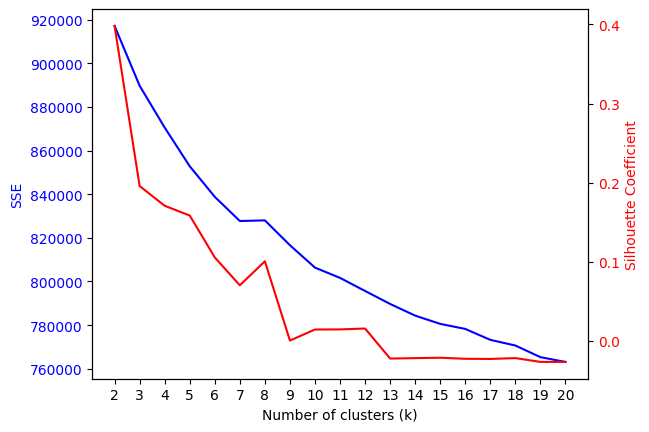

In [192]:
import matplotlib.pyplot as plt

K = range(2, 21)

fig, ax1 = plt.subplots()

ax1.plot(K, sse, 'b')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('SSE', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(K)

ax2 = ax1.twinx()
ax2.plot(K, sil, 'r')
ax2.set_ylabel('Silhouette Coefficient', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.show()

Θα αναλύσουμε αρχικά και τις δύο μετρικές.  
Όσον αφορά το **sillhouette score** αυτό που μπορούμε να παρατηρήσουμε είναι πως μειώνεται όσο αυξάνεται το πλήθος των clusters. Για **k=2** είναι υψηλό(περίπου 0.4) και μειώνεται απότομα μέχρι το **k=3**. Μετά συνεχίζει και πέφτει και για k=8 αυξάνεται λίγο. Στα k=10-12 είναι σχεδόν σταθερό, αμέσως μετά έχει μια πτώση και τελικά για k>13 φαίνεται να σταθεροποιείται. Για το **sse** αυτό που μπορούμε να παρατηρήσουμε πως διαρκώς πέφτει αλλά όχι ομαλά. Δεν μπορούμε να διακρίνουμε με σαφήνεια το γόνατο.
Η βέλτιστη τιμή για το **k** που θα επιλέξουμε είναι η **k=5**. Ο λόγος είναι διότι εκεί έχουμε αρκετά υψηλό  **sillhouette score** ενώ παράλληλα εκεί παρατηρείται μία σχετικά απότομη πτώση του **sse**. Άλλη μια πιθανή τιμή θα μπορούσε να είναι η **k=8** όπου το **sse** είναι χαμηλότερο και το **sillhouette score** έχει μια απότομη άνοδο αλλά είναι ελαφρώς χαμηλότερο από πριν. Ο λόγος που δεν το κάναμε είναι ότι δεν φαίνεται να έχει και ουσιαστική διαφορά και ακολουθούμε το **Occam's Razor** όπου μεταξύ δύο μοντέλων με σχεδόν ίδια απόδοση, επιλέγουμε το απλούστερο.
Ωστόσο θα πρέπει να επισημάνουμε πως δεν φαίνεται και κάποια ξεκάθαρη ευνοικότερη τιμή για το k, τουλάχιστον όπως στο παράδειγμα στο φροντιστήριο.

### 2) Agglomerative Clustering

Αφού εφαρμόσαμε τον kmeans και βρήκαμε το βέλτιστο k, θα χρησιμοποιήσουμε αυτήν την τιμή για να εφαρμόσουμε και το **Agglomerative Clustering**. Θα χρησιμοποιήσουμε το complete linkage όπως και στο φροντιστήριο. Το Agglomerative Clustering δεν δέχεται αραιούς πίνακες, οπότε θα πρέπει να μετατρέψουμε τον R σε dense.

In [193]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(linkage = 'complete', n_clusters = 5)
R_dense = R.toarray()
agglo_labels = agglo.fit_predict(R_dense) # evala to R kai petaxe error oti thelei dense

In [194]:
agglo_sil_score = silhouette_score(R_dense,agglo_labels)

In [195]:
print("Sillhouette score of Agglomerative Clustering is ",agglo_sil_score)
print("Sillhouette score of Kmeans Clustering is ",sil[3])

Sillhouette score of Agglomerative Clustering is  0.45601561809234115
Sillhouette score of Kmeans Clustering is  0.1586109326860461


Για k=5, ο k-means αλγόριθμος πέτυχε silhouette score 0.15, γεγονός που υποδηλώνει σχετικά αδύναμη συνοχή των clusters. Αντίθετα, ο agglomerative clustering με complete linkage πέτυχε σημαντικά υψηλότερο silhouette score (0.45), υποδεικνύοντας καλύτερο διαχωρισμό και μεγαλύτερη συνοχή των clusters, δηλαδή μεγαλύτερη ομοιότητα των ταινιών μέσα σε κάθε cluster.

### Αξιολόγηση Clustering

Το επόμενο που θα κάνουμε είναι να εξάγουμε τα genres των ταινιών.

Για το clustering λάβαμε υπόψη τα ratings των χρηστών. Τώρα πρέπει να το αξιολογήσουμε με βάση τα genres. Πετάμε τις διπλές εγγραφές των ταινιών αφού δεν μας νοιάζουν τα ratings πλέον. Όπως εξηγήσαμε και πριν τα id των ταινιών είναι πολύ περισσότερα από τον αριθμό ταινιών. Για να αντοιστιχίσουμε τα labels που έβγαλε ο k-means για k=5 με τις ταινίες, κάνουμε unique για να πάρουμε τα id με τη σειρά εμφάνισης στον πίνακα και έπειτα κάνουμε map στα labels των clusters.

In [196]:
import ast
ratings['genres'] = ratings['genres'].apply(ast.literal_eval)

In [197]:
df_movies = ratings[['movieId', 'genres']].drop_duplicates(subset='movieId').copy()

movie_ids = df_movies['movieId'].unique() #gia na parei ta monadika id me th seira
df_movies['cluster'] = df_movies['movieId'].map(dict(zip(movie_ids, kmeans_labels[3]))) # for k=5

df_movies = df_movies.explode('genres')
df_movies = df_movies.dropna(subset=['genres'])
df_movies['genres'] = df_movies['genres'].apply(lambda x: x['name'])
df_movies = df_movies.reset_index(drop=True)
df_movies

,movieId,genres,cluster
0,31,Drama,1
1,31,Crime,1
2,1029,Animation,2
3,1029,Family,2
4,1061,Crime,1
...,...,...,...
6007,2961,Romance,1
6008,1963,Comedy,1
6009,1963,Crime,1
6010,1414,Comedy,1


Βρίσκουμε την συχνότητα των genres σε κάθε cluster

In [198]:
cluster_genre_freq = df_movies.groupby(['cluster', 'genres']).size().reset_index(name='count')
cluster_genre_freq

,cluster,genres,count
0,0,Action,58
1,0,Adventure,49
2,0,Animation,14
3,0,Comedy,57
4,0,Crime,36
...,...,...,...
82,4,Mystery,3
83,4,Romance,7
84,4,Science Fiction,15
85,4,Thriller,14


In [199]:
for cluster_num, group in cluster_genre_freq.groupby('cluster'):
    print(f"\nCluster {cluster_num}:")
    sorted_group = group.sort_values('count', ascending=False) # sort by descending
    for _, row in sorted_group.iterrows():
        print(f"{row['genres']}: {row['count']}")


Cluster 0:
Drama: 75
Action: 58
Comedy: 57
Thriller: 51
Adventure: 49
Crime: 36
Science Fiction: 35
Fantasy: 25
Family: 23
Romance: 21
Mystery: 18
Animation: 14
Horror: 8
War: 7
History: 6
Music: 6
Documentary: 2
Western: 1

Cluster 1:
Drama: 713
Comedy: 582
Thriller: 417
Action: 387
Adventure: 330
Romance: 311
Crime: 254
Science Fiction: 234
Fantasy: 186
Family: 178
Mystery: 137
Horror: 123
Animation: 89
Music: 68
History: 56
War: 40
Western: 31
Documentary: 22

Cluster 2:
Drama: 247
Comedy: 173
Romance: 102
Thriller: 77
Crime: 65
Action: 56
Adventure: 52
Mystery: 37
Family: 33
Science Fiction: 32
Fantasy: 31
History: 29
War: 24
Music: 22
Animation: 18
Horror: 15
Western: 8
Documentary: 4

Cluster 3:
Action: 21
Drama: 21
Thriller: 20
Adventure: 15
Comedy: 13
Romance: 11
Crime: 10
Fantasy: 8
Science Fiction: 7
Family: 7
Mystery: 7
Animation: 3
War: 1
History: 1
Music: 1
Horror: 1
Western: 1

Cluster 4:
Drama: 30
Comedy: 23
Adventure: 22
Action: 20
Fantasy: 15
Science Fiction: 15
Thril

Βλέπουμε ότι στα περισσότερα clusters το πιο συχνό είδος είναι το **Drama** και ακολουθεί το **Comedy**. Το 4ο cluster έχει μια μικρή διαφορά με ισοβαθμία **Drama** και **Action** με το **Thriller** να ακολουθεί. Επομένως αυτός δεν είναι και πολύ κατάλληλος τρόπος αξιολόγησης, καθώς τα Drama και Comedy είναι πολύ συχνά στο dataset.

In [200]:
df_movies['genres'].value_counts()

genres
Drama              1086
Comedy              848
Thriller            579
Action              542
Adventure           468
Romance             452
Crime               378
Science Fiction     323
Fantasy             265
Family              251
Mystery             202
Horror              151
Animation           128
Music                98
History              95
War                  77
Western              41
Documentary          28
Name: count, dtype: int64

#### Lift

Φτιάχνουμε ένα data frame όπου κάθε genre σε κάθε cluster έχει την συχνότητα που εμφανίζεται στο cluster και την συχνότητα συνολικά και μετά υπολογίζουμε το lift

In [201]:
df_movies

,movieId,genres,cluster
0,31,Drama,1
1,31,Crime,1
2,1029,Animation,2
3,1029,Family,2
4,1061,Crime,1
...,...,...,...
6007,2961,Romance,1
6008,1963,Comedy,1
6009,1963,Crime,1
6010,1414,Comedy,1


In [202]:
cluster_sizes = df_movies['cluster'].value_counts()
# total frequency for each genre
total_genre_freq = df_movies['genres'].value_counts()

df_lift = cluster_genre_freq.copy()
df_lift = df_lift.merge(total_genre_freq.rename('total_count'), left_on='genres', right_index=True)
df_lift = df_lift.merge(cluster_sizes.rename('cluster_size'), left_on='cluster', right_index=True)

In [203]:
total_movies = len(df_movies)
# lift = (meros sto cluster) / (meros synolika)
#  (count / cluster_size) / (total_count / total_movies)
df_lift['lift'] = (df_lift['count'] / df_lift['cluster_size']) / (df_lift['total_count'] / total_movies)
df_lift

,cluster,genres,count,total_count,cluster_size,lift
0,0,Action,58,542,492,1.307623
1,0,Adventure,49,468,492,1.279393
2,0,Animation,14,128,492,1.336509
3,0,Comedy,57,848,492,0.821359
4,0,Crime,36,378,492,1.163763
...,...,...,...,...,...,...
82,4,Mystery,3,202,189,0.472419
83,4,Romance,7,452,189,0.492625
84,4,Science Fiction,15,323,189,1.477222
85,4,Thriller,14,579,189,0.769142


Στη συνέχεια βρίσκουμε για κάθε cluster τα genres με τα 3 μεγαλύτερα lift

In [204]:
top_3_per_cluster = df_lift.sort_values(['cluster', 'lift'], ascending=[True, False]).groupby('cluster').head(3)

for cluster in sorted(top_3_per_cluster['cluster'].unique()):
    cluster_data = top_3_per_cluster[top_3_per_cluster['cluster'] == cluster]
    print("\n")
    print(f"cluster {cluster}:")
    for _, row in cluster_data.iterrows():
        print(f"{row['genres']}: lift = {row['lift']:.3f}")



cluster 0:
Animation: lift = 1.337
Science Fiction: lift = 1.324
Action: lift = 1.308


cluster 1:
Horror: lift = 1.178
Documentary: lift = 1.136
Western: lift = 1.093


cluster 2:
War: lift = 1.828
History: lift = 1.790
Drama: lift = 1.334


cluster 3:
Action: lift = 1.574
Mystery: lift = 1.408
Thriller: lift = 1.403


cluster 4:
War: lift = 2.066
Fantasy: lift = 1.801
Adventure: lift = 1.495


Αυτή η μέθοδος φαίνεται πιο κατάλληλη για να αξιολογήσουμε το clustering, αφού βλέπουμε γενικά διαφορετικά genres με υψηλότερο lift σε κάθε ομάδα. Οι τιμές είναι όλες πάνω από 1 άρα τα genres χαρακτηρίζουν αρκετά καλά τα clusters. Οι ομάδες λοιπόν φαίνεται να αναπαριστούν κατά το πλήστον διαφορετικά είδη αξιολογήσεων χρηστών αφού κυριαρχούν διαφορετικά είδη ταινιών σε κάθε ομάδα. Η 3η και 5η ομάδα ίσως είναι παρόμοιες καθώς έχουν το **War** με υψηλότερο σκορ.

### PCA

Εδώ αντιμετωπίσαμε ένα μικρό θέμα. Επειδή ο R είναι αραιός πίνακας, όταν το τρέχαμε στο collab η pca μόνο με προσδιορισμό της παραμέτρου **n_components** έτρεχε κανονικά, όμως όταν το τρέχαμε locally στο jupyter έβγαζε error και έλεγε ότι για να τρέξει με αραιό πίνακα πρέπει ο solver να είναι **arpack** και όχι auto που είναι το default. Επειδή δεν αναφέρει πουθενά στην εκφώνηση να τον κάνουμε dense, απλά αλλάξαμε τον τύπο του solver.

In [205]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50,svd_solver='arpack', random_state=3) # an krasarei
#pca = PCA(n_components=50, random_state=3)
rpca = pca.fit_transform(R)
print(rpca.shape)

(2242, 50)


In [206]:
kmeans_pca = KMeans(n_clusters=5, random_state=3)
kmeans_pca.fit_predict(rpca)
labels_pca = kmeans_pca.labels_

In [207]:
pca_sil_score = silhouette_score(R,labels_pca)

In [208]:
print("Sillhouette score of PCA is ",pca_sil_score)
print("Sillhouette score of Kmeans Clustering is ",sil[3])

Sillhouette score of PCA is  0.05881829776512292
Sillhouette score of Kmeans Clustering is  0.1586109326860461


Για 5 clusters το Sillhouette score με τη μέθοδο PCA βγαίνει πολύ μικρότερο. Ίσως μια διαφορετική τιμή ομάδων να είναι πιο κατάλληλη εδώ.

In [209]:
sse_pca = []
sil_pca = []
kmeans_labels_pca = []
K = range(2,21)

for k in K:
    kmeans_pca = KMeans(n_clusters=k, max_iter=100, random_state=3)
    kmeans_pca.fit_predict(rpca)
    sse_pca.append(kmeans_pca.inertia_)
    sil_pca.append(silhouette_score(R,kmeans_pca.labels_))
    kmeans_labels_pca.append(kmeans_pca.labels_)
    print("Finished k =",k)

Finished k = 2
Finished k = 3
Finished k = 4
Finished k = 5
Finished k = 6
Finished k = 7
Finished k = 8
Finished k = 9
Finished k = 10
Finished k = 11
Finished k = 12
Finished k = 13
Finished k = 14
Finished k = 15
Finished k = 16
Finished k = 17
Finished k = 18
Finished k = 19
Finished k = 20


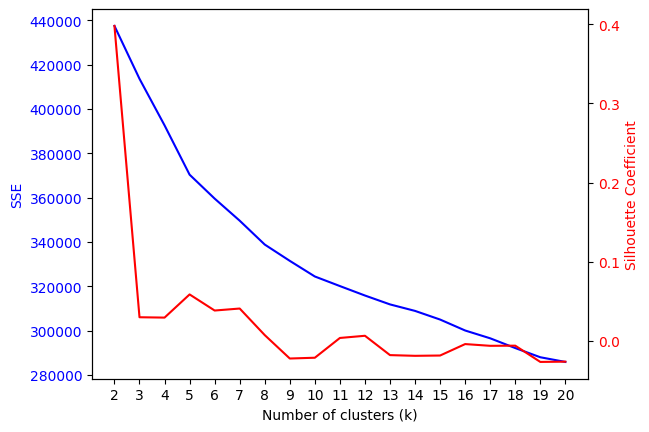

In [210]:

K = range(2, 21)

fig, ax1 = plt.subplots()

ax1.plot(K, sse_pca, 'b')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('SSE', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(K)

ax2 = ax1.twinx()
ax2.plot(K, sil_pca, 'r')
ax2.set_ylabel('Silhouette Coefficient', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.show()

Από το γράφημα παρατηρούμε ότι γενικά το sse έχει χαμηλότερο εύρος από πριν. Και το Silhouette score είναι γενικά χαμηλότερο. Η τιμή k=5 φαίνεται να είναι η ιδανική.

Για την αξιολόγηση του PCA χρησιμοποιούμε πάλι το lift των genres για αριθμό ομάδων k=5.

In [211]:
df_movies_pca = ratings[['movieId', 'genres']].drop_duplicates(subset='movieId').copy()

movie_ids = df_movies_pca['movieId'].unique() #gia na parei ta monadika id me th seira
df_movies_pca['cluster'] = df_movies_pca['movieId'].map(dict(zip(movie_ids, kmeans_labels_pca[3]))) # for k=5

df_movies_pca = df_movies_pca.explode('genres')
df_movies_pca = df_movies_pca.dropna(subset=['genres'])
df_movies_pca['genres'] = df_movies_pca['genres'].apply(lambda x: x['name'])
df_movies_pca = df_movies_pca.reset_index(drop=True)
df_movies_pca

,movieId,genres,cluster
0,31,Drama,2
1,31,Crime,2
2,1029,Animation,4
3,1029,Family,4
4,1061,Crime,2
...,...,...,...
6007,2961,Romance,2
6008,1963,Comedy,2
6009,1963,Crime,2
6010,1414,Comedy,2


In [212]:
cluster_genre_freq = df_movies_pca.groupby(['cluster', 'genres']).size().reset_index(name='count')
cluster_sizes = df_movies_pca['cluster'].value_counts()
# total frequency for each genre
total_genre_freq = df_movies_pca['genres'].value_counts()

df_lift = cluster_genre_freq.copy()
df_lift = df_lift.merge(total_genre_freq.rename('total_count'), left_on='genres', right_index=True)
df_lift = df_lift.merge(cluster_sizes.rename('cluster_size'), left_on='cluster', right_index=True)

In [213]:
total_movies = len(df_movies_pca)
# lift = (meros sto cluster) / (meros synolika)
#  (count / cluster_size) / (total_count / total_movies)
df_lift['lift'] = (df_lift['count'] / df_lift['cluster_size']) / (df_lift['total_count'] / total_movies)
df_lift

,cluster,genres,count,total_count,cluster_size,lift
0,0,Action,153,542,1173,1.446815
1,0,Adventure,127,468,1173,1.390845
2,0,Animation,33,128,1173,1.321371
3,0,Comedy,129,848,1173,0.779677
4,0,Crime,72,378,1173,0.976251
...,...,...,...,...,...,...
82,4,Romance,82,452,926,1.177832
83,4,Science Fiction,28,323,926,0.562812
84,4,Thriller,75,579,926,0.840990
85,4,War,21,77,926,1.770666


In [214]:
top_3_per_cluster = df_lift.sort_values(['cluster', 'lift'], ascending=[True, False]).groupby('cluster').head(3)

for cluster in sorted(top_3_per_cluster['cluster'].unique()):
    cluster_data = top_3_per_cluster[top_3_per_cluster['cluster'] == cluster]
    print("\n")
    print(f"cluster {cluster}:")
    for _, row in cluster_data.iterrows():
        print(f"{row['genres']}: lift = {row['lift']:.3f}")



cluster 0:
Science Fiction: lift = 1.619
Action: lift = 1.447
Adventure: lift = 1.391


cluster 1:
Fantasy: lift = 1.675
Adventure: lift = 1.542
Science Fiction: lift = 1.432


cluster 2:
Documentary: lift = 1.315
Horror: lift = 1.254
Music: lift = 1.199


cluster 3:
Action: lift = 1.535
Mystery: lift = 1.497
Thriller: lift = 1.437


cluster 4:
History: lift = 1.914
War: lift = 1.771
Music: lift = 1.391


Και σε αυτή τη μέθοδο παρόλο το χαμηλό Silhouette score, βλέπουμε καλά αποτελέσματα με το μεγαλύτερο lift σε κάθε ομάδα να ανήκει σε διαφορετική ταινία. Όλα τα αποτελέσματα είναι μεγαλύτερα του 1 και επομένως φαίνεται τα cluster να έχουν καλή συχσέτιση ως προς το είδος των ταινιών από τις αξιολογήσεις των χρηστών.

### Επιπλέον Αξιολόγηση

Μπορούμε να κάνουμε μια παρόμοια διαδικασία με πριν που βρίσκαμε την συχνότητα genres στα clusters. Θα κάνουμε το ίδιο αλλά αυτή τη φορά θα βρούμε τις πιο συχνές δεκαετίες που κυκλοφόρησαν οι ταινίες στα clusters.

In [215]:
df_movies2 = ratings[['movieId', 'release_date']].drop_duplicates(subset='movieId').copy()
df_movies2['release_date'] = pd.to_datetime(df_movies2['release_date'])
df_movies2['decade'] = df_movies2['release_date'].apply(lambda x : (x.year // 10)*10)
df_movies2.head()

,movieId,release_date,decade
0,31,1995-08-11,1990
1,1029,1941-10-22,1940
2,1061,1996-10-18,1990
3,1129,1981-05-22,1980
4,1172,1988-11-17,1980


In [216]:
movie_ids = df_movies2['movieId'].unique() #gia na parei ta monadika id me th seira
df_movies2['cluster'] = df_movies2['movieId'].map(dict(zip(movie_ids, kmeans_labels[3]))) # for k=5
df_movies2.head()


,movieId,release_date,decade,cluster
0,31,1995-08-11,1990,1
1,1029,1941-10-22,1940,2
2,1061,1996-10-18,1990,1
3,1129,1981-05-22,1980,2
4,1172,1988-11-17,1980,2


Υπολογίζουμε το lift όπως πριν για καλύτερα αποτελέσματα.

In [217]:
cluster_decade_freq = df_movies2.groupby(['cluster', 'decade']).size().reset_index(name='count')
cluster_sizes = df_movies2['cluster'].value_counts()
# total frequency for each decade
total_decade_freq = df_movies2['decade'].value_counts()

df_lift = cluster_decade_freq.copy()
df_lift = df_lift.merge(total_decade_freq.rename('total_count'), left_on='decade', right_index=True)
df_lift = df_lift.merge(cluster_sizes.rename('cluster_size'), left_on='cluster', right_index=True)

In [218]:
total_movies = len(df_movies2)
# lift = (μέρος στο cluster) / (μέρος συνολικά)
# = (count / cluster_size) / (total_count / total_movies)
df_lift['lift'] = (df_lift['count'] / df_lift['cluster_size']) / (df_lift['total_count'] / total_movies)
df_lift

,cluster,decade,count,total_count,cluster_size,lift
0,0,1980,4,339,173,0.152915
1,0,1990,25,844,173,0.383873
2,0,2000,134,584,173,2.973593
3,0,2010,10,130,173,0.996888
4,1,1920,7,7,1538,1.457737
5,1,1930,15,27,1538,0.809854
6,1,1940,15,36,1538,0.607391
7,1,1950,34,68,1538,0.728869
8,1,1960,54,91,1538,0.865031
9,1,1970,63,116,1538,0.791702


In [219]:
top_3_per_cluster = df_lift.sort_values(['cluster', 'lift'], ascending=[True, False]).groupby('cluster').head(3)

for cluster in sorted(top_3_per_cluster['cluster'].unique()):
    cluster_data = top_3_per_cluster[top_3_per_cluster['cluster'] == cluster]
    print("\n")
    print(f"cluster {cluster}:")
    for _, row in cluster_data.iterrows():
        print(f"{row['decade']}: lift = {row['lift']:.3f}")



cluster 0:
2000.0: lift = 2.974
2010.0: lift = 0.997
1990.0: lift = 0.384


cluster 1:
1920.0: lift = 1.458
2010.0: lift = 1.346
2000.0: lift = 1.093


cluster 2:
1940.0: lift = 3.038
1950.0: lift = 2.734
1930.0: lift = 2.228


cluster 3:
1990.0: lift = 2.602
1980.0: lift = 0.135


cluster 4:
1970.0: lift = 3.221
1980.0: lift = 2.205
1930.0: lift = 1.153


Βλέπουμε ότι σε κάθε ομάδα η δεκαετία με το μεγαλύτερο lift είναι διαφορετική. Παρατηρούμε ότι η αξιολόγηση από τους χρήστες έχει χωριστεί καλά σε κάποιες ομάδες και φαίνονται κάποια μοτίβα. Στην πρώτη ομάδα έχουμε πιο πρόσφατες ταινίες, κυρίως της δεκαετίας 2000. Οι υπόλοιπες τιμές είναι μικρότερες του 1 και μάλλον δεν έχουν μεγάλη συσχέτιση. Στην 3η ομάδα βλέπουμε τις δεκαετίες 30'-50' και στην 4η κυρίως την δεκαετία του 90'. Στην τελευταία, τις δεκαετίες 70'-80' αλλά και 30', που ίσως χαλάει λίγο την ομαδοποίηση αυτού του cluster. Η 2η ομάδα φαίνεται να έχει την χειρότερη ομαδοποίηση.